In [7]:
import pandas as pd
import kagglehub
path = kagglehub.dataset_download("ahmedmashal/cyclistics-bike-share-2023")

Using Colab cache for faster access to the 'cyclistics-bike-share-2023' dataset.


In [8]:
import os
print(os.listdir(path))

['202505-divvy-tripdata.csv', '202504-divvy-tripdata.csv', '202509-divvy-tripdata.csv', '202511-divvy-tripdata.csv', '202502-divvy-tripdata.csv', '202512-divvy-tripdata.csv', '202506-divvy-tripdata.csv', '202507-divvy-tripdata.csv', '202503-divvy-tripdata.csv', '202501-divvy-tripdata.csv', '202508-divvy-tripdata.csv', '202510-divvy-tripdata.csv']


In [9]:
import glob
files = glob.glob(path + "/*.csv")

In [10]:
df = pd.concat(
    [
        pd.read_csv(
            f,
            usecols=[
                "ride_id",
                "rideable_type",
                "started_at",
                "ended_at",
                "start_station_name",
                "end_station_name",
                "start_lat",
                "start_lng",
                "member_casual"
                ]
            )
        for f in files
        ],
    ignore_index=True
    )
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,end_station_name,start_lat,start_lng,member_casual
0,BADF67E2C5058F19,classic_bike,2025-05-11 17:22:39.471,2025-05-11 18:11:19.249,DuSable Lake Shore Dr & North Blvd,Winthrop Ave & Lawrence Ave,41.911722,-87.626804,member
1,0210AE485D59C8C5,electric_bike,2025-05-05 08:02:09.251,2025-05-05 08:12:07.549,Damen Ave & Grand Ave,Desplaines St & Jackson Blvd,41.892394,-87.676885,member
2,5E68FE5B9283E4C4,classic_bike,2025-05-02 10:32:33.062,2025-05-02 10:39:07.262,LaSalle St & Illinois St,Clark St & Elm St,41.890762,-87.631697,member
3,13D2DCD6FB872858,classic_bike,2025-05-12 11:12:16.579,2025-05-12 11:17:25.126,Milwaukee Ave & Rockwell St,Damen Ave & Cortland St,41.920330,-87.693090,member
4,F04DF9EE163351DD,classic_bike,2025-05-01 10:13:36.821,2025-05-01 10:17:40.548,Halsted St & Roosevelt Rd,Clinton St & Roosevelt Rd,41.867324,-87.648625,member


In [11]:
#Convert dates
df['started_at'] = pd.to_datetime(df["started_at"])
df["ended_at"]= pd.to_datetime(df["ended_at"])
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,end_station_name,start_lat,start_lng,member_casual
0,BADF67E2C5058F19,classic_bike,2025-05-11 17:22:39.471,2025-05-11 18:11:19.249,DuSable Lake Shore Dr & North Blvd,Winthrop Ave & Lawrence Ave,41.911722,-87.626804,member
1,0210AE485D59C8C5,electric_bike,2025-05-05 08:02:09.251,2025-05-05 08:12:07.549,Damen Ave & Grand Ave,Desplaines St & Jackson Blvd,41.892394,-87.676885,member
2,5E68FE5B9283E4C4,classic_bike,2025-05-02 10:32:33.062,2025-05-02 10:39:07.262,LaSalle St & Illinois St,Clark St & Elm St,41.890762,-87.631697,member
3,13D2DCD6FB872858,classic_bike,2025-05-12 11:12:16.579,2025-05-12 11:17:25.126,Milwaukee Ave & Rockwell St,Damen Ave & Cortland St,41.920330,-87.693090,member
4,F04DF9EE163351DD,classic_bike,2025-05-01 10:13:36.821,2025-05-01 10:17:40.548,Halsted St & Roosevelt Rd,Clinton St & Roosevelt Rd,41.867324,-87.648625,member


In [12]:
#Travel time
df["ride_length"] = (df['ended_at'] - df['started_at']).dt.total_seconds()/60

#Delete negative ride lengths
df = df[df['ride_length'] >=0]

#Delete rides < 1 min
df = df[df['ride_length'] >=1]

df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,end_station_name,start_lat,start_lng,member_casual,ride_length
0,BADF67E2C5058F19,classic_bike,2025-05-11 17:22:39.471,2025-05-11 18:11:19.249,DuSable Lake Shore Dr & North Blvd,Winthrop Ave & Lawrence Ave,41.911722,-87.626804,member,48.662967
1,0210AE485D59C8C5,electric_bike,2025-05-05 08:02:09.251,2025-05-05 08:12:07.549,Damen Ave & Grand Ave,Desplaines St & Jackson Blvd,41.892394,-87.676885,member,9.971633
2,5E68FE5B9283E4C4,classic_bike,2025-05-02 10:32:33.062,2025-05-02 10:39:07.262,LaSalle St & Illinois St,Clark St & Elm St,41.890762,-87.631697,member,6.570000
3,13D2DCD6FB872858,classic_bike,2025-05-12 11:12:16.579,2025-05-12 11:17:25.126,Milwaukee Ave & Rockwell St,Damen Ave & Cortland St,41.920330,-87.693090,member,5.142450
4,F04DF9EE163351DD,classic_bike,2025-05-01 10:13:36.821,2025-05-01 10:17:40.548,Halsted St & Roosevelt Rd,Clinton St & Roosevelt Rd,41.867324,-87.648625,member,4.062117


In [13]:
#Fill missing stations
df['start_station_name'] = df['start_station_name'].fillna("Unknown_Station")
df['end_station_name'] = df['end_station_name'].fillna("Unknown_Station")

#Delete duplicate data
df = df.drop_duplicates()

df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,end_station_name,start_lat,start_lng,member_casual,ride_length
0,BADF67E2C5058F19,classic_bike,2025-05-11 17:22:39.471,2025-05-11 18:11:19.249,DuSable Lake Shore Dr & North Blvd,Winthrop Ave & Lawrence Ave,41.911722,-87.626804,member,48.662967
1,0210AE485D59C8C5,electric_bike,2025-05-05 08:02:09.251,2025-05-05 08:12:07.549,Damen Ave & Grand Ave,Desplaines St & Jackson Blvd,41.892394,-87.676885,member,9.971633
2,5E68FE5B9283E4C4,classic_bike,2025-05-02 10:32:33.062,2025-05-02 10:39:07.262,LaSalle St & Illinois St,Clark St & Elm St,41.890762,-87.631697,member,6.570000
3,13D2DCD6FB872858,classic_bike,2025-05-12 11:12:16.579,2025-05-12 11:17:25.126,Milwaukee Ave & Rockwell St,Damen Ave & Cortland St,41.920330,-87.693090,member,5.142450
4,F04DF9EE163351DD,classic_bike,2025-05-01 10:13:36.821,2025-05-01 10:17:40.548,Halsted St & Roosevelt Rd,Clinton St & Roosevelt Rd,41.867324,-87.648625,member,4.062117


In [14]:
#Day of week
df['day_of_week'] = df['started_at'].dt.day_name()

#Hour
df['hour'] = df['started_at'].dt.hour

#Month
df['month'] = df['started_at'].dt.month_name()

df.head()


,ride_id,rideable_type,started_at,ended_at,start_station_name,end_station_name,start_lat,start_lng,member_casual,ride_length,day_of_week,hour,month
0,BADF67E2C5058F19,classic_bike,2025-05-11 17:22:39.471,2025-05-11 18:11:19.249,DuSable Lake Shore Dr & North Blvd,Winthrop Ave & Lawrence Ave,41.911722,-87.626804,member,48.662967,Sunday,17,May
1,0210AE485D59C8C5,electric_bike,2025-05-05 08:02:09.251,2025-05-05 08:12:07.549,Damen Ave & Grand Ave,Desplaines St & Jackson Blvd,41.892394,-87.676885,member,9.971633,Monday,8,May
2,5E68FE5B9283E4C4,classic_bike,2025-05-02 10:32:33.062,2025-05-02 10:39:07.262,LaSalle St & Illinois St,Clark St & Elm St,41.890762,-87.631697,member,6.570000,Friday,10,May
3,13D2DCD6FB872858,classic_bike,2025-05-12 11:12:16.579,2025-05-12 11:17:25.126,Milwaukee Ave & Rockwell St,Damen Ave & Cortland St,41.920330,-87.693090,member,5.142450,Monday,11,May
4,F04DF9EE163351DD,classic_bike,2025-05-01 10:13:36.821,2025-05-01 10:17:40.548,Halsted St & Roosevelt Rd,Clinton St & Roosevelt Rd,41.867324,-87.648625,member,4.062117,Thursday,10,May


In [15]:
#Weekend
df['is_weekend'] = df['started_at'].dt.weekday >= 5

df.head(10)

,ride_id,rideable_type,started_at,ended_at,start_station_name,end_station_name,start_lat,start_lng,member_casual,ride_length,day_of_week,hour,month,is_weekend
0,BADF67E2C5058F19,classic_bike,2025-05-11 17:22:39.471,2025-05-11 18:11:19.249,DuSable Lake Shore Dr & North Blvd,Winthrop Ave & Lawrence Ave,41.911722,-87.626804,member,48.662967,Sunday,17,May,True
1,0210AE485D59C8C5,electric_bike,2025-05-05 08:02:09.251,2025-05-05 08:12:07.549,Damen Ave & Grand Ave,Desplaines St & Jackson Blvd,41.892394,-87.676885,member,9.971633,Monday,8,May,False
2,5E68FE5B9283E4C4,classic_bike,2025-05-02 10:32:33.062,2025-05-02 10:39:07.262,LaSalle St & Illinois St,Clark St & Elm St,41.890762,-87.631697,member,6.570000,Friday,10,May,False
3,13D2DCD6FB872858,classic_bike,2025-05-12 11:12:16.579,2025-05-12 11:17:25.126,Milwaukee Ave & Rockwell St,Damen Ave & Cortland St,41.920330,-87.693090,member,5.142450,Monday,11,May,False
4,F04DF9EE163351DD,classic_bike,2025-05-01 10:13:36.821,2025-05-01 10:17:40.548,Halsted St & Roosevelt Rd,Clinton St & Roosevelt Rd,41.867324,-87.648625,member,4.062117,Thursday,10,May,False
5,D68970C8A0234C01,electric_bike,2025-05-18 22:17:12.177,2025-05-18 22:33:43.514,LaSalle St & Illinois St,Racine Ave & Belmont Ave,41.890762,-87.631697,member,16.522283,Sunday,22,May,True
6,A9BD55C04D298E4E,classic_bike,2025-05-16 16:41:32.603,2025-05-16 16:53:00.409,Field Blvd & South Water St,Clark St & Elm St,41.886349,-87.617517,member,11.463433,Friday,16,May,False
7,B9F6C711D340B656,electric_bike,2025-05-03 17:03:48.470,2025-05-03 17:07:09.437,Halsted St & Roosevelt Rd,Clinton St & Roosevelt Rd,41.867324,-87.648625,casual,3.349450,Saturday,17,May,True
8,EA9D207866ADA9B6,electric_bike,2025-05-17 15:20:41.924,2025-05-17 15:25:40.931,LaSalle St & Illinois St,Clark St & Elm St,41.890762,-87.631697,casual,4.983450,Saturday,15,May,True
9,A3CEF22A4196F6CC,electric_bike,2025-05-30 09:40:46.809,2025-05-30 09:47:54.357,DuSable Lake Shore Dr & North Blvd,Unknown_Station,41.911722,-87.626804,member,7.125800,Friday,9,May,False


In [16]:
#Shape of the dataframe
df.shape

(5405593, 14)

In [17]:
#Member vs Casual distribution
df['member_casual'].value_counts()

,count
member_casual,
member,3485110
casual,1920483


In [18]:
#Percentage of member and casual
df['member_casual'].value_counts(normalize=True) * 100

,proportion
member_casual,
member,64.472297
casual,35.527703


In [19]:
#Average cycling trip duration by user type
df.groupby('member_casual')['ride_length'].mean()

,ride_length
member_casual,
casual,23.509521
member,12.567106


In [20]:
#Median duration
df.groupby('member_casual')['ride_length'].median()

,ride_length
member_casual,
casual,11.924033
member,8.740000


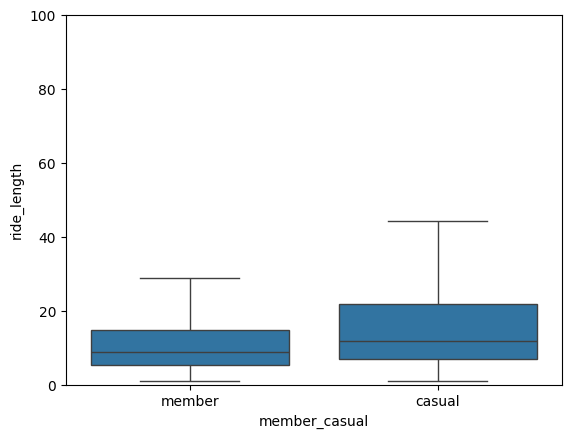

In [21]:
#Visualization
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data = df, x = 'member_casual', y = 'ride_length', showfliers = False)
plt.ylim(0, 100)
plt.show()

In [22]:
#Number of ride per day
daily_rides = df.groupby(['member_casual', 'day_of_week']).size().reset_index(name='rides')
daily_rides

,member_casual,day_of_week,rides
0,casual,Friday,307258
1,casual,Monday,219749
2,casual,Saturday,396657
3,casual,Sunday,317850
4,casual,Thursday,248420
5,casual,Tuesday,217363
6,casual,Wednesday,213186
7,member,Friday,518681
8,member,Monday,493437
9,member,Saturday,440019


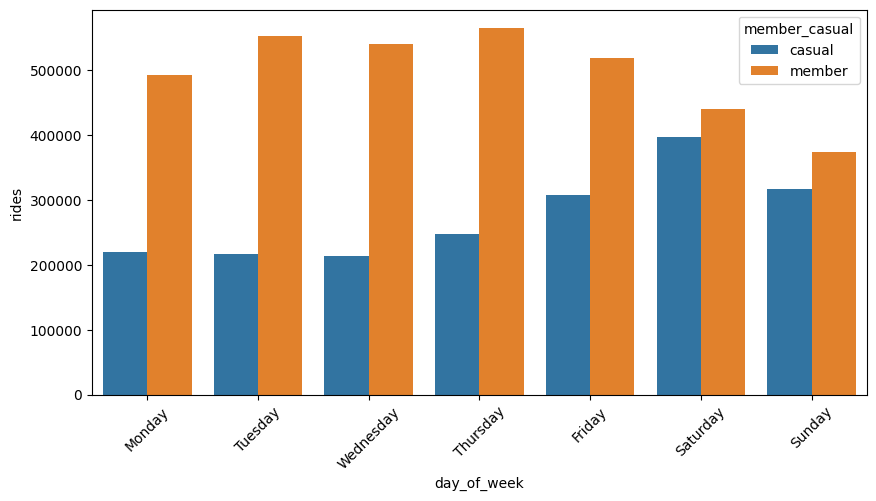

In [23]:
#Visualization of usage per day of the week
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

plt.figure(figsize=(10, 5))
sns.barplot(data = daily_rides, x = 'day_of_week', y = 'rides', hue = 'member_casual', order = day_order)
plt.xticks(rotation=45)
plt.show()

In [24]:
#Usage per hour
rides_by_hour = df.groupby(['hour', 'member_casual']).size().reset_index(name='rides')
rides_by_hour

,hour,member_casual,rides
0,0,casual,36921
1,0,member,31412
2,1,casual,23598
3,1,member,19116
4,2,casual,15751
5,2,member,11437
6,3,casual,8765
7,3,member,7528
8,4,casual,6965
9,4,member,8610


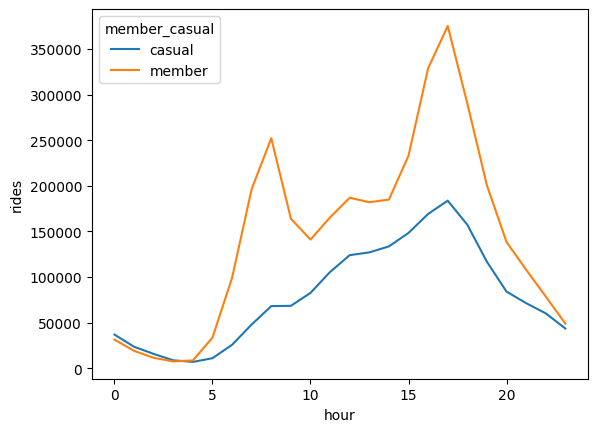

In [25]:
#visualization
sns.lineplot(data = rides_by_hour, x='hour', y='rides', hue='member_casual')
plt.show()

In [26]:
#Distribution by type of bicycle
bike_type = df.groupby(['rideable_type', 'member_casual']).size().reset_index(name='rides')
bike_type

,rideable_type,member_casual,rides
0,classic_bike,casual,672670
1,classic_bike,member,1275359
2,electric_bike,casual,1247813
3,electric_bike,member,2209751


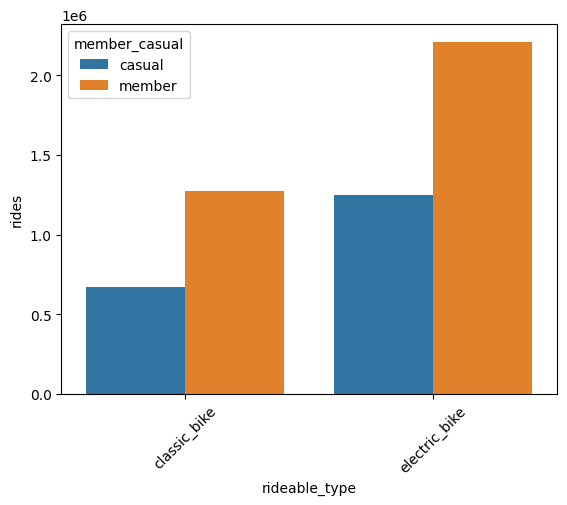

In [27]:
#Visualization
sns.barplot(data = bike_type, x='rideable_type', y='rides', hue='member_casual')
plt.xticks(rotation=45)
plt.show()

In [28]:
#Weekend vs weekday comparison
df['week-end_weekday'] = df['is_weekend'].map({True: "Week-end", False: "Weekday"})

week_usage = df.groupby(['week-end_weekday', 'member_casual']).size().reset_index(name='rides')
week_usage

,week-end_weekday,member_casual,rides
0,Week-end,casual,714507
1,Week-end,member,814672
2,Weekday,casual,1205976
3,Weekday,member,2670438


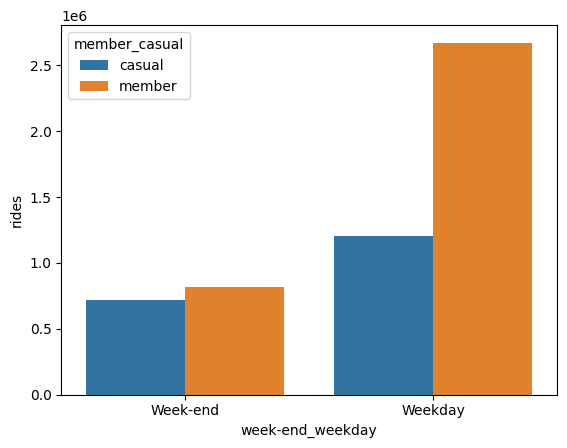

In [29]:
#Visualization
sns.barplot(data = week_usage, x="week-end_weekday", y="rides", hue="member_casual")
plt.show()

In [30]:
#Station count
df['start_station_name'].value_counts().head(10)

,count
start_station_name,
Unknown_Station,1095321
Kingsbury St & Kinzie St,40188
DuSable Lake Shore Dr & Monroe St,38977
Michigan Ave & Oak St,34647
Navy Pier,34570
DuSable Lake Shore Dr & North Blvd,33234
Clinton St & Washington Blvd,30339
Streeter Dr & Grand Ave,29658
Clark St & Elm St,29571


In [31]:
#Casual's top stations
casual_stations = (df[df["member_casual"] == "casual"]["start_station_name"].value_counts().head(10))
casual_stations

,count
start_station_name,
Unknown_Station,378958
DuSable Lake Shore Dr & Monroe St,30796
Navy Pier,26971
Streeter Dr & Grand Ave,23367
Michigan Ave & Oak St,22123
DuSable Lake Shore Dr & North Blvd,19071
Millennium Park,18819
Shedd Aquarium,16553
Theater on the Lake,15491


In [32]:
#Member's top stations
member_stations = (df[df["member_casual"] == "member"]["start_station_name"].value_counts().head(10))
member_stations

,count
start_station_name,
Unknown_Station,716363
Kingsbury St & Kinzie St,30894
Clinton St & Washington Blvd,25304
Canal St & Madison St,21843
Clinton St & Madison St,21820
Clark St & Elm St,20607
State St & Chicago Ave,18827
Wells St & Elm St,18667
Wells St & Concord Ln,18110


In [33]:
df.to_csv("bike_cleaned.csv", index=False)

In [34]:
from google.colab import drive
drive.mount('/content/drive')

df.to_csv("/content/drive/MyDrive/bike_cleaned.csv", index=False)

Mounted at /content/drive


In [35]:
#Monthly rides
month_ride = df.groupby(['month', 'member_casual']).size().reset_index(name='rides')
month_ride

,month,member_casual,rides
0,April,casual,105528
1,April,member,257962
2,August,casual,324165
3,August,member,443214
4,December,casual,27195
5,December,member,109419
6,February,casual,27051
7,February,member,122118
8,January,casual,23453
9,January,member,112352


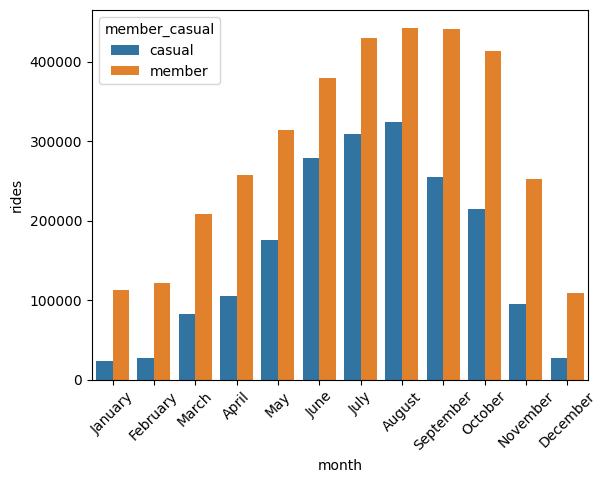

In [36]:
#Visualization
month_order = ("January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December")
sns.barplot(data = month_ride, x='month', y= 'rides', hue= 'member_casual', order= month_order)
plt.xticks(rotation= 45)
plt.show()